### Demonstrates how to create Langchain Agents, wrap them into A2A server, how to create A2A client and how it discovers other Agents

# 🌍 A2A Protocol + LangChain + LangGraph — Smart Travel Planner

> Updated for `venv-agents-requirements-lock.txt` — LangChain **1.3.9**, LangGraph **1.2.5**, a2a-sdk **0.2.5**, FastAPI **0.121.2**.

---

## Architecture: Pattern C — LangGraph Orchestrator + LangChain A2A Agents

```
👤 User Query: "Plan a 5-day trip to Tokyo"
        │
        ▼  LangGraph StateGraph (5 nodes)
┌──────────────────────────────────────────────────────────────────────┐
│  🔷 Node 1: parse_query        ← LangChain LCEL (ChatOpenAI)       │
│              ↓                                                       │
│  🔷 Node 2: research_destination  ← A2A JSON-RPC → :8001           │
│                                      └─ LangChain 1.x agent + Wikipedia │
│              ↓                                                       │
│  🔷 Node 3: check_weather          ← A2A JSON-RPC → :8002          │
│                                      └─ LangChain 1.x agent + wttr.in  │
│              ↓                                                       │
│  🔷 Node 4: estimate_budget        ← A2A JSON-RPC → :8003          │
│                                      └─ LangChain 1.x agent + Cost DB  │
│              ↓                                                       │
│  🔷 Node 5: synthesize_plan    ← LangChain LCEL (ChatOpenAI)       │
└──────────────────────────────────────────────────────────────────────┘
        │
        ▼
📋 Comprehensive AI-written Travel Plan
```

## What makes this different from the plain A2A notebook?

| Component | Plain A2A | This Notebook (Pattern C) |
|---|---|---|
| Specialist Agent Logic | Plain Python functions | **LangChain 1.x `create_agent`** (tool-using LLM) |
| Orchestration | `TravelOrchestrator` class | **LangGraph StateGraph** (5-node pipeline) |
| Intent Parsing | Regex | **LangChain LCEL + ChatOpenAI** |
| Final Report | String concatenation | **LangChain LLM synthesis** (natural language plan) |
| A2A Protocol | ✅ JSON-RPC 2.0 | ✅ JSON-RPC 2.0 (unchanged — framework-agnostic!) |

## Learning Objectives
1. Build LangChain 1.x `create_agent`s with custom and built-in tools
2. Use LangChain LCEL chains for intent parsing and synthesis
3. Model a multi-agent workflow as a **LangGraph StateGraph**
4. Wrap LangChain agents in A2A-compliant FastAPI servers
5. Understand how A2A is **framework-agnostic** (protocol stays the same)
6. Trace complete state evolution through LangGraph nodes
## Key API updates vs `a2a_langgraph_travel_planner.ipynb`

| Old (LangChain 0.2.x) | New (LangChain 1.x) |
|---|---|
| `create_react_agent` + `AgentExecutor` | `create_agent` |
| `PromptTemplate` ReAct scratchpad prompt | `system_prompt` parameter |
| `ainvoke({"input": ...})` | `ainvoke({"messages": [HumanMessage(...)]})` |
| `result["output"]` | `result["messages"][-1].content` |


## 📦 Section 0 — Install Dependencies

Pinned versions from `venv-agents-requirements-lock.txt`. Run once in a fresh environment.

In [ ]:
# Run once in a fresh environment
#%pip install \
#    a2a-sdk==0.2.5 \
#    fastapi==0.121.2 \
#    uvicorn==0.38.0 \
#    httpx==0.28.1 \
#    pydantic==2.12.5 \
#    nest-asyncio==1.6.0 \
#    langchain==1.3.9 \
#    langchain-openai==1.3.2 \
#    langchain-community==0.4.2 \
#    langchain-core==1.4.7 \
#    langgraph==1.2.5 \
#    langgraph-prebuilt==1.1.0 \
#    openai==2.42.0 \
#    python-dotenv==1.2.2 \
#    wikipedia==1.4.0 \
#    pandas==2.2.2 \
#    matplotlib==3.10.3

---
## 📦 Section 1 — Setup & Imports

In [1]:
# ── Async support in Jupyter ──────────────────────────────────────────────────
import nest_asyncio
nest_asyncio.apply()

# ── Standard library ─────────────────────────────────────────────────────────
import asyncio, json, uuid, time, threading, logging, re, os
from datetime import datetime
from typing import List, Optional, Dict, Any, Annotated, TypedDict
from enum import Enum
import operator

# ── A2A Server / HTTP ─────────────────────────────────────────────────────────
from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse
# for hosting ASGI server (Asynchronous Server gateway Interface) we use uvicorn
import uvicorn
import httpx

# ── Data models ───────────────────────────────────────────────────────────────
from pydantic import BaseModel, Field

# ── LangChain 1.x ─────────────────────────────────────────────────────────────
from langchain_openai import ChatOpenAI
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain.agents import create_agent
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.tools import tool as lc_tool
from langchain_core.messages import HumanMessage

# ── LangGraph ─────────────────────────────────────────────────────────────────
from langgraph.graph import StateGraph, END, START

# ── Visualisation ─────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

# ── Silence noisy logs ───────────────────────────────────────────────────────
for _lg in ["uvicorn", "uvicorn.access", "fastapi", "httpx",
            "openai", "langchain", "httpcore"]:
    logging.getLogger(_lg).setLevel(logging.ERROR)

print("✅ All imports successful!")
print("   FastAPI + Uvicorn   → A2A agent HTTP servers")
print("   HTTPX               → A2A client calls (JSON-RPC 2.0)")
print("   LangChain 1.x       → create_agent + LCEL chains inside each A2A agent")
print("   LangGraph           → StateGraph orchestrator (5-node pipeline)")
print("   nest_asyncio        → Async in Jupyter")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31880\3947767508.py:24: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import WikipediaQueryRun


✅ All imports successful!
   FastAPI + Uvicorn   → A2A agent HTTP servers
   HTTPX               → A2A client calls (JSON-RPC 2.0)
   LangChain 1.x       → create_agent + LCEL chains inside each A2A agent
   LangGraph           → StateGraph orchestrator (5-node pipeline)
   nest_asyncio        → Async in Jupyter


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LLM SETUP — configure your OpenAI API key before running
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from dotenv import load_dotenv
from openai import (APIConnectionError, AuthenticationError, NotFoundError,
                    PermissionDeniedError, RateLimitError)
load_dotenv()   # reads OPENAI_API_KEY from .env file if present

# ── Option A: set via .env file (recommended)
# ── Option B: set directly below
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")

if not OPENAI_API_KEY or OPENAI_API_KEY == "":
    print("⚠️  OPENAI_API_KEY not found in environment.")
    print("   Please set it in a .env file or uncomment the line below:")
    # OPENAI_API_KEY = "sk-...your-key..."
else:
    masked = OPENAI_API_KEY[:8] + "..." + OPENAI_API_KEY[-4:]
    print(f"✅ OPENAI_API_KEY found: {masked}")

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

MODEL_NAME = "gpt-4o-mini"   # fast and cost-effective; change to gpt-4o for higher quality

# Shared LLM instance used by all LangChain agents and the LangGraph synthesizer
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
synthesis_llm = ChatOpenAI(model=MODEL_NAME, temperature=0.3)  # slightly creative for final plan

print(f"\n✅ LLM configured: {MODEL_NAME}")
print(f"   llm           → temperature=0  (deterministic, for agents)")
print(f"   synthesis_llm → temperature=0.3 (creative, for final plan)")


# ── Verify the key actually works: one tiny LLM call (~15 tokens, a tiny fraction of a cent)
def verify_openai_key(model: str) -> None:
    """Call the LLM once to confirm the key is valid, has quota, and can use the model."""
    probe = ChatOpenAI(model=model, temperature=0, max_tokens=5, max_retries=0, timeout=20)
    try:
        reply = probe.invoke("Reply with the single word: OK")
    except AuthenticationError:
        reason = "Invalid API key (401). Check the value in .env, or the key may have been revoked."
    except PermissionDeniedError:
        reason = "Key is valid but lacks permission (403). Check the key's project/organization settings."
    except RateLimitError as exc:
        if "insufficient_quota" in str(exc):
            reason = "Key is valid but the account has no credit (insufficient_quota). Add billing at platform.openai.com."
        else:
            reason = "Rate limit hit (429). Wait a moment and re-run this cell."
    except NotFoundError:
        reason = f"Key is valid but model '{model}' is not available to this account (404)."
    except APIConnectionError:
        reason = "Could not reach api.openai.com. Check your internet connection / proxy."
    else:
        print(f"\n✅ API key verified — {model} replied: {reply.content.strip()!r}")
        return
    print(f"\n❌ API key check failed: {reason}")
    raise RuntimeError(f"OpenAI API key check failed: {reason}")


verify_openai_key(MODEL_NAME)

✅ OPENAI_API_KEY found: sk-proj-...wpsA

✅ LLM configured: gpt-4o-mini
   llm           → temperature=0  (deterministic, for agents)
   synthesis_llm → temperature=0.3 (creative, for final plan)

✅ API key verified — gpt-4o-mini replied: 'OK'


---
## 🏗️ Section 2 — A2A Protocol Data Models

These models are **identical** to the plain A2A notebook.  
This demonstrates a core A2A principle: **the protocol is framework-agnostic**.  
Switching from plain Python to LangChain inside the agents requires **zero changes** to the A2A layer.

In [3]:
### Agent Card - is the JSON format information about the agent. What it does, the end point, authentication required and so on.
### Helps other agents to understand how to use this.
### If you want other agents to use your agent yiu must implement and support A2A protocol 

In [4]:
### Task is a stateful unit of work. Holds what task is initiated by the agent, for how long it is going on etc..

In [5]:
### message - communication media between agent and client. used to give instructions, Q and answer, updates etc..

In [6]:
### TextPart - text content within message. Used to pass file reference, URL or structured data etc..

In [7]:
### artifacts -  to pass image, document, structured data during a task you can use artifact

In [3]:
## we will try to use a2a-sdk (try block). If not available for any reason, we define equivalent code do achieve the same result.

try:
    from a2a.types import (AgentCard, AgentSkill, AgentCapabilities,
                            Task, TaskState, Message, TextPart)
    print("✅ Using official a2a-sdk types")
except Exception:
    print("ℹ️  a2a-sdk not importable — using equivalent custom Pydantic models")

class TaskState(str, Enum):
    SUBMITTED = "submitted"; WORKING = "working"
    COMPLETED = "completed"; FAILED  = "failed"; CANCELLED = "cancelled"

class TextPart(BaseModel):
    type: str = "text"; text: str

class Message(BaseModel):
    messageId: str = Field(default_factory=lambda: str(uuid.uuid4()))
    role: str; parts: List[TextPart]
    timestamp: str = Field(default_factory=lambda: datetime.now().isoformat())

class TaskStatus(BaseModel):
    state: TaskState = TaskState.SUBMITTED
    message: Optional[Message] = None

class Task(BaseModel):
    id: str = Field(default_factory=lambda: str(uuid.uuid4()))
    status: TaskStatus = Field(default_factory=TaskStatus)
    history: List[Message] = []

class AgentSkill(BaseModel):
    id: str; name: str; description: str
    tags: List[str] = []; examples: List[str] = []

class AgentCapabilities(BaseModel):
    streaming: bool = False; pushNotifications: bool = False

class AgentCard(BaseModel):
    """A2A Agent Manifest — served at /.well-known/agent.json."""
    name: str; description: str; url: str; version: str = "1.0.0"
    capabilities: AgentCapabilities = Field(default_factory=AgentCapabilities)
    skills: List[AgentSkill] = []

class JSONRPCRequest(BaseModel):
    jsonrpc: str = "2.0"
    id: str = Field(default_factory=lambda: str(uuid.uuid4()))
    method: str; params: Dict[str, Any] = {}

class JSONRPCResponse(BaseModel):
    jsonrpc: str = "2.0"; id: str
    result: Optional[Any] = None
    error: Optional[Dict[str, Any]] = None

print("\n✅ A2A Protocol Models ready (unchanged from plain A2A notebook)")
print("   ↳ Proof that A2A is truly framework-agnostic!")

✅ Using official a2a-sdk types

✅ A2A Protocol Models ready (unchanged from plain A2A notebook)
   ↳ Proof that A2A is truly framework-agnostic!


---
## 🔧 Section 3 — A2A Agent Factory & Client
Also **identical** to the plain notebook — the factory wraps any async handler into an A2A-compliant FastAPI app.

whatever agent we creare later can be warpped to become an A2A compliant agent. It takes in agent card and handler as inputs and returns FastAPI app.

Whatever agent you may create later it can be wrapped to c]become an A2A compliant Agent. Takes in agent card and handler as inputs and returns FastAPI app.

In [4]:
## Agents communicate over http as a transport protocol. This is lower level in network communication layers.
## Focus of http is how data moves from point A to point B
## JSON-RPC protocol is used for sending agent-2-agent messages. This is at higher level. Data format or action/execution leyer.
## Focus of JSON-RPC is How one machine executes function on another machine 

### This function takes in Agent Card and hanlder as an arhument and returns FastAPI application.

### Agent Card - is the JSON format information about the agent. What it does, the end point, authentication required and so on.
### Helps other agents to understand how to use this.
### If you want other agents to use your agent yiu must implement and support A2A protocol 

def create_a2a_agent(agent_card: AgentCard, handler) -> FastAPI:
    """
    Factory: wraps ANY async handler (plain Python or LangChain agent)
    into an A2A-compliant FastAPI app with:
      GET  /.well-known/agent.json  (discovery)
      POST /                        (JSON-RPC 2.0 message/send)
    """
    app = FastAPI(title=agent_card.name, docs_url=None)

    @app.get("/.well-known/agent.json")
    async def get_agent_card():
        return agent_card.model_dump()

    @app.post("/")
    async def handle_jsonrpc(request: Request):
        body = await request.json()
        rpc  = JSONRPCRequest(**body)
        if rpc.method == "message/send":
            try:
                msg  = rpc.params.get("message", {})
                ctx  = rpc.params.get("context", {})
                text = "".join(p.get("text", "") for p in msg.get("parts", [])
                               if p.get("type") == "text")
                response_text = await handler(text, ctx)
                return JSONResponse({
                    "jsonrpc": "2.0", "id": rpc.id,
                    "result": {"messageId": str(uuid.uuid4()), "role": "agent",
                               "parts": [{"type": "text", "text": response_text}]}
                })
            except Exception as exc:
                return JSONResponse({"jsonrpc": "2.0", "id": rpc.id,
                                     "error": {"code": -32603, "message": str(exc)}})
        return JSONResponse({"jsonrpc": "2.0", "id": rpc.id,
                             "error": {"code": -32601,
                                       "message": f"Unknown method: {rpc.method}"}})
    return app

### A2A Client
class A2AClient:
    """Async HTTP client that speaks the A2A JSON-RPC 2.0 protocol."""

    def __init__(self, base_url: str, agent_name: str = ""):
        self.base_url = base_url; self.agent_name = agent_name

    async def discover(self) -> AgentCard:
        async with httpx.AsyncClient(timeout=10.0, verify=False) as c:
            r = await c.get(f"{self.base_url}/.well-known/agent.json")
            r.raise_for_status()
            return AgentCard(**r.json())

    async def send(self, text: str, context: Dict = None) -> str:
        payload = JSONRPCRequest(
            method="message/send",
            params={"message": {"messageId": str(uuid.uuid4()), "role": "user",
                                "parts": [{"type": "text", "text": text}]},
                    "context": context or {}}
        )
        async with httpx.AsyncClient(timeout=60.0) as c:
            r = await c.post(self.base_url, json=payload.model_dump(),
                             headers={"Content-Type": "application/json"})
            r.raise_for_status()
            result = r.json().get("result", {})
            return "".join(p.get("text", "") for p in result.get("parts", [])
                           if p.get("type") == "text")

# Registry
AGENT_REGISTRY = {
    "destination" : "http://localhost:8001",
    "weather"     : "http://localhost:8002",
    "budget"      : "http://localhost:8003",
}

print("✅ A2A Factory and Client ready (unchanged — framework-agnostic protocol layer)")

✅ A2A Factory and Client ready (unchanged — framework-agnostic protocol layer)


---
## 🤖 Section 4 — LangChain Specialist Agents

This is where the notebooks diverge. Each specialist agent now uses a **LangChain 1.x `create_agent`** internally.

### LangChain 1.x agent Pattern
```
Input text
   │
   ▼
LLM decides when to call tools
   │
   ▼  loop until done
tool_calls → ToolMessage → next model turn
   │
   ▼
LLM: "I now have enough info"
   │
   ▼
Final Answer (returned to A2A caller)
```

The **A2A layer is identical** — handlers now call `create_agent` with `system_prompt` and `messages` (LangChain 1.x API).

### System prompts
Each specialist agent passes a `system_prompt` to `create_agent` (no shared ReAct template needed).

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LANGCHAIN AGENT 1 — Destination Research Agent  (port 8001)
#   Framework : LangChain 1.x create_agent
#   Tool      : WikipediaQueryRun (langchain-community)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

destination_card = AgentCard(
    name="Destination Research Agent",
    description="Researches travel destinations using Wikipedia via a LangChain 1.x agent.",
    url="http://localhost:8001",
    skills=[AgentSkill(
        id="research_destination", name="Research Destination",
        description="Fetch comprehensive overview of any travel destination",
        tags=["travel", "research", "wikipedia", "langchain"],
        examples=["Research destination: Paris", "Tell me about Tokyo"]
    )]
)

_wiki_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=3000)
)

_dest_agent = create_agent(
    model=llm,
    tools=[_wiki_tool],
    system_prompt=(
        "You are a knowledgeable travel destination researcher. "
        "Use the Wikipedia tool to gather facts, then write a comprehensive overview "
        "covering attractions, culture, history, and travel tips."
    ),
    debug=True,
)

async def destination_handler(text: str, context: Dict = None) -> str:
    """A2A handler — delegates to LangChain 1.x create_agent."""
    try:
        result = await _dest_agent.ainvoke(
            {"messages": [HumanMessage(content=(
                f"Research this travel destination and provide a comprehensive overview "
                f"covering attractions, culture, history, and travel tips: {text}"
            ))]},
            config={"recursion_limit": 8},
        )
        return result["messages"][-1].content or "No destination information found."
    except Exception as exc:
        import wikipedia
        dest = re.sub(r'(?i)(research|destination:|tell me about)', '', text).strip()
        try:
            summary = wikipedia.summary(dest, sentences=5)
            return f"📍 {dest.upper()}\n\n{summary}\n\n[Note: LLM unavailable — {exc}]"
        except Exception:
            return f"⚠️ Could not research '{dest}': {exc}"

destination_app = create_a2a_agent(destination_card, destination_handler)

print("✅ Agent 1 — Destination Research Agent (LangChain 1.x create_agent)")
print(f"   URL       : {destination_card.url}")
print(f"   Framework : langchain.agents.create_agent")
print(f"   Tool      : WikipediaQueryRun")
print(f"   LLM       : {MODEL_NAME} (via ChatOpenAI)")

✅ Agent 1 — Destination Research Agent (LangChain 1.x create_agent)
   URL       : http://localhost:8001
   Framework : langchain.agents.create_agent
   Tool      : WikipediaQueryRun
   LLM       : gpt-4o-mini (via ChatOpenAI)


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LANGCHAIN AGENT 2 — Weather Intelligence Agent  (port 8002)
#   Framework : LangChain 1.x create_agent
#   Tool      : Custom async tool → wttr.in API (free, no key)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

weather_card = AgentCard(
    name="Weather Intelligence Agent",
    description="Provides weather conditions via LangChain 1.x agent + custom wttr.in tool.",
    url="http://localhost:8002",
    skills=[AgentSkill(
        id="get_weather", name="Get Current Weather",
        description="Return live weather conditions with travel advice",
        tags=["weather", "climate", "langchain"],
        examples=["Weather for Tokyo", "What's the weather in Paris?"]
    )]
)

@lc_tool
async def fetch_weather_data(city: str) -> str:
    """Fetch current weather data for a city from the wttr.in public API."""
    try:
        async with httpx.AsyncClient(timeout=12.0) as client:
            r = await client.get(
                f"https://wttr.in/{city}?format=j1",
                headers={"User-Agent": "LangChain-A2A-Demo/1.0"}
            )
        if r.status_code != 200:
            return f"Weather service returned HTTP {r.status_code} for '{city}'"
        data    = r.json()
        cur     = data["current_condition"][0]
        area    = data["nearest_area"][0]
        country = area["country"][0]["value"]
        return (
            f"City: {city}, Country: {country}, "
            f"Temp: {cur['temp_C']}°C ({cur['temp_F']}°F), "
            f"FeelsLike: {cur['FeelsLikeC']}°C, "
            f"Humidity: {cur['humidity']}%, "
            f"Wind: {cur['windspeedKmph']} km/h, "
            f"Visibility: {cur['visibility']} km, "
            f"Conditions: {cur['weatherDesc'][0]['value']}"
        )
    except Exception as exc:
        return f"Weather data unavailable for '{city}': {str(exc)[:80]}"

_weather_agent = create_agent(
    model=llm,
    tools=[fetch_weather_data],
    system_prompt=(
        "You are a weather intelligence specialist for travelers. "
        "Use the weather tool, then summarize conditions with practical packing and activity advice."
    ),
    debug=True,
)

async def weather_handler(text: str, context: Dict = None) -> str:
    """A2A handler — LangChain 1.x agent with wttr.in tool."""
    try:
        result = await _weather_agent.ainvoke(
            {"messages": [HumanMessage(content=(
                f"Get the current weather for the travel destination mentioned and "
                f"provide a helpful weather summary with travel advice: {text}"
            ))]},
            config={"recursion_limit": 6},
        )
        return result["messages"][-1].content or "Weather information unavailable."
    except Exception as exc:
        return f"🌤️ Weather data unavailable ({exc}). Please check your API key and internet connection."

weather_app = create_a2a_agent(weather_card, weather_handler)

print("✅ Agent 2 — Weather Intelligence Agent (LangChain 1.x create_agent)")
print(f"   URL       : {weather_card.url}")
print(f"   Framework : langchain.agents.create_agent")
print(f"   Tool      : fetch_weather_data (custom @lc_tool → wttr.in)")
print(f"   LLM       : {MODEL_NAME} (via ChatOpenAI)")

✅ Agent 2 — Weather Intelligence Agent (LangChain 1.x create_agent)
   URL       : http://localhost:8002
   Framework : langchain.agents.create_agent
   Tool      : fetch_weather_data (custom @lc_tool → wttr.in)
   LLM       : gpt-4o-mini (via ChatOpenAI)


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LANGCHAIN AGENT 3 — Budget Estimator Agent  (port 8003)
#   Framework : LangChain 1.x create_agent
#   Tool      : Custom tool → in-memory cost database (offline)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

COST_DB: Dict[str, Dict] = {
    "paris"     : {"hotel": 150, "food": 60, "transport": 20, "activities": 40, "currency": "EUR", "fx": 0.92},
    "tokyo"     : {"hotel": 120, "food": 50, "transport": 25, "activities": 35, "currency": "JPY", "fx": 150},
    "new york"  : {"hotel": 220, "food": 80, "transport": 15, "activities": 55, "currency": "USD", "fx": 1.0},
    "london"    : {"hotel": 180, "food": 65, "transport": 20, "activities": 45, "currency": "GBP", "fx": 0.79},
    "bali"      : {"hotel": 60,  "food": 25, "transport": 12, "activities": 25, "currency": "IDR", "fx": 15600},
    "dubai"     : {"hotel": 160, "food": 70, "transport": 18, "activities": 50, "currency": "AED", "fx": 3.67},
    "singapore" : {"hotel": 140, "food": 55, "transport": 20, "activities": 40, "currency": "SGD", "fx": 1.34},
    "rome"      : {"hotel": 130, "food": 55, "transport": 15, "activities": 35, "currency": "EUR", "fx": 0.92},
    "barcelona" : {"hotel": 120, "food": 50, "transport": 15, "activities": 35, "currency": "EUR", "fx": 0.92},
    "amsterdam" : {"hotel": 145, "food": 60, "transport": 18, "activities": 40, "currency": "EUR", "fx": 0.92},
    "default"   : {"hotel": 100, "food": 45, "transport": 18, "activities": 30, "currency": "USD", "fx": 1.0},
}

budget_card = AgentCard(
    name="Budget Estimator Agent",
    description="Estimates travel budget via LangChain 1.x agent + cost database tool.",
    url="http://localhost:8003",
    skills=[AgentSkill(
        id="estimate_budget", name="Estimate Travel Budget",
        description="Calculate itemized travel budget with LLM-written advice",
        tags=["budget", "finance", "langchain"],
        examples=["Budget for 5 days in Tokyo", "How much for a week in Bali?"]
    )]
)

@lc_tool
def lookup_travel_costs(destination: str) -> str:
    """Look up mid-range daily travel cost estimates for a destination."""
    key   = destination.lower().strip()
    costs = COST_DB.get(key, COST_DB["default"])
    found = key in COST_DB
    daily = costs["hotel"] + costs["food"] + costs["transport"] + costs["activities"]
    note  = "(exact city data)" if found else "(global average — city not in database)"
    return (
        f"Destination: {destination} {note} | "
        f"Hotel: ${costs['hotel']}/day | Food: ${costs['food']}/day | "
        f"Transport: ${costs['transport']}/day | Activities: ${costs['activities']}/day | "
        f"Daily total: ${daily} | Local currency: {costs['currency']} | "
        f"FX: 1 USD = {costs['fx']} {costs['currency']}"
    )

_budget_agent = create_agent(
    model=llm,
    tools=[lookup_travel_costs],
    system_prompt=(
        "You are a travel budget specialist. Use the cost lookup tool, then write an "
        "itemized budget with daily breakdown, total cost, local currency notes, and money-saving tips."
    ),
    debug=True,
)

async def budget_handler(text: str, context: Dict = None) -> str:
    """A2A handler — LangChain 1.x agent with cost database tool."""
    try:
        result = await _budget_agent.ainvoke(
            {"messages": [HumanMessage(content=(
                f"Calculate an itemized travel budget for this query. "
                f"Show daily breakdown, total cost, local currency conversion, "
                f"and practical money-saving tips: {text}"
            ))]},
            config={"recursion_limit": 6},
        )
        return result["messages"][-1].content or "Budget information unavailable."
    except Exception as exc:
        return f"💰 Budget estimation failed ({exc}). Please check your API key."

budget_app = create_a2a_agent(budget_card, budget_handler)

print("✅ Agent 3 — Budget Estimator Agent (LangChain 1.x create_agent)")
print(f"   URL       : {budget_card.url}")
print(f"   Framework : langchain.agents.create_agent")
print(f"   Tool      : lookup_travel_costs (custom @lc_tool → COST_DB, fully offline)")
print(f"   LLM       : {MODEL_NAME} (via ChatOpenAI)")

✅ Agent 3 — Budget Estimator Agent (LangChain 1.x create_agent)
   URL       : http://localhost:8003
   Framework : langchain.agents.create_agent
   Tool      : lookup_travel_costs (custom @lc_tool → COST_DB, fully offline)
   LLM       : gpt-4o-mini (via ChatOpenAI)


#### Now all the three sub-agents are ready in A2A compliant format we will create multiple nodes in langgraph. Langgraph Nodes will each invoke A2A client and then "send" method. Langgraph nodes 

---
## 🎯 Section 5 — LangGraph Orchestrator (Pattern C)

The orchestrator is now a **LangGraph `StateGraph`** — a directed acyclic graph where:
- **State** flows through nodes, accumulating information
- Each **node** is an async function that reads from state, does work, and returns state updates
- **Edges** define the execution order
- The **A2A protocol** is used in nodes 2–4 to call specialist agents. Node 1 is for parsing the user query and taking further steps.

```
TravelState (TypedDict)
┌─────────────────────────────────────────────────┐
│ query, destination, duration                    │
│ destination_info, weather_info, budget_info     │
│ final_plan, task_id                             │
│ node_log: Annotated[List, operator.add]  ←──── accumulates across all nodes
└─────────────────────────────────────────────────┘
```

### Why `Annotated[List, operator.add]` for `node_log`?
In LangGraph, when a node returns a dict, each key **replaces** the existing value by default.  
The `Annotated[List, operator.add]` type annotation tells LangGraph to **append** instead of replace — so each node's log entry is preserved.

In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LANGGRAPH — State Schema + Node Functions
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── 1. State Schema ──────────────────────────────────────────────────────────
class TravelState(TypedDict):
    """
    Shared state that flows through the LangGraph pipeline.
    node_log uses Annotated[List, operator.add] so each node APPENDS
    to the log rather than overwriting it.
    """
    query:            str
    destination:      str
    duration:         str
    destination_info: str
    weather_info:     str
    budget_info:      str
    final_plan:       str
    task_id:          str
    node_log:         Annotated[List[str], operator.add]   # accumulates!

# Global audit log populated by the synthesize_plan node
langgraph_task_log: List[Dict] = []

# ── 2. Node 1 — parse_query (LangChain LCEL) ─────────────────────────────────
async def parse_query_node(state: TravelState) -> dict:
    """
    Uses LangChain LCEL (ChatPromptTemplate | ChatOpenAI | StrOutputParser)
    to extract destination and duration from the user's natural-language query.
    Falls back to regex if LLM is unavailable.
    """
    print(f"\n🔷 [NODE 1] parse_query")
    query = state["query"]
    task_id = str(uuid.uuid4())[:8]

    try:
        chain = (
            ChatPromptTemplate.from_messages([
                ("system", "Extract travel destination and duration from queries. "
                           "If duration is not mentioned, default to '3 days'. "
                           "Reply ONLY in the exact format shown."),
                ("human",  "Query: {query}\n\nReply ONLY:\ndestination: <city>\nduration: <N days>")
            ])
            | synthesis_llm
            | StrOutputParser()
        )
        text    = await chain.ainvoke({"query": query})
        dest_m  = re.search(r"destination:\s*(.+)", text, re.IGNORECASE)
        dur_m   = re.search(r"duration:\s*(.+)",    text, re.IGNORECASE)
        destination = dest_m.group(1).strip() if dest_m else "Paris"
        duration    = dur_m.group(1).strip()  if dur_m  else "3 days"
    except Exception as exc:
        print(f"   ⚠️ LLM parsing failed ({exc}) — using regex fallback")
        m_dest = re.search(r'(?:trip to|visit|to|in)\s+([A-Za-z][A-Za-z ]{2,}?)(?:\s+for|\s*$)',
                           query, re.IGNORECASE)
        m_dur  = re.search(r'(\d+)\s*(day|days|week|weeks)', query, re.IGNORECASE)
        destination = m_dest.group(1).strip().title() if m_dest else "Paris"
        duration    = m_dur.group(0).strip()          if m_dur  else "3 days"

    print(f"   → Destination : {destination}")
    print(f"   → Duration    : {duration}")
    print(f"   → Task ID     : {task_id}")

    return {
        "destination" : destination,
        "duration"    : duration,
        "task_id"     : task_id,
        "node_log"    : [f"[{task_id}] parse_query → dest={destination}, dur={duration}"]
    }

# ── 3. Node 2 — research_destination (A2A call → LangChain 1.x agent :8001) ───────
async def research_destination_node(state: TravelState) -> dict:
    """
    Calls the Destination Research Agent via A2A protocol (JSON-RPC POST :8001).
    The receiving agent uses LangChain 1.x agent + WikipediaQueryRun internally.
    """
    print(f"\n🔷 [NODE 2] research_destination  →  A2A call :8001")
    t0     = time.time()
    result = await A2AClient("http://localhost:8001").send(
        f"Research destination: {state['destination']}",
        {"task_id": state["task_id"], "from_agent": "langgraph_orchestrator"}
    )
    elapsed = round(time.time() - t0, 2)
    print(f"   ✅ {len(result)} chars received in {elapsed}s")
    return {
        "destination_info": result,
        "node_log": [f"[{state['task_id']}] research_destination → A2A :8001 ({elapsed}s)"]
    }

# ── 4. Node 3 — check_weather (A2A call → LangChain 1.x agent :8002) ──────────────
async def check_weather_node(state: TravelState) -> dict:
    """
    Calls the Weather Intelligence Agent via A2A protocol (JSON-RPC POST :8002).
    The receiving agent uses LangChain 1.x agent + custom wttr.in tool internally.
    """
    print(f"\n🔷 [NODE 3] check_weather  →  A2A call :8002")
    t0     = time.time()
    result = await A2AClient("http://localhost:8002").send(
        f"Weather for {state['destination']}",
        {"task_id": state["task_id"], "from_agent": "langgraph_orchestrator"}
    )
    elapsed = round(time.time() - t0, 2)
    print(f"   ✅ {len(result)} chars received in {elapsed}s")
    return {
        "weather_info": result,
        "node_log": [f"[{state['task_id']}] check_weather → A2A :8002 ({elapsed}s)"]
    }

# ── 5. Node 4 — estimate_budget (A2A call → LangChain 1.x agent :8003) ────────────
async def estimate_budget_node(state: TravelState) -> dict:
    """
    Calls the Budget Estimator Agent via A2A protocol (JSON-RPC POST :8003).
    The receiving agent uses LangChain 1.x agent + cost database tool internally.
    """
    print(f"\n🔷 [NODE 4] estimate_budget  →  A2A call :8003")
    t0     = time.time()
    result = await A2AClient("http://localhost:8003").send(
        f"Budget for {state['duration']} in {state['destination']}",
        {"task_id": state["task_id"], "from_agent": "langgraph_orchestrator"}
    )
    elapsed = round(time.time() - t0, 2)
    print(f"   ✅ {len(result)} chars received in {elapsed}s")
    return {
        "budget_info": result,
        "node_log": [f"[{state['task_id']}] estimate_budget → A2A :8003 ({elapsed}s)"]
    }

# ── 6. Node 5 — synthesize_plan (LangChain LCEL synthesis with ChatOpenAI) ────
async def synthesize_plan_node(state: TravelState) -> dict:
    """
    Uses LangChain LCEL (ChatPromptTemplate | ChatOpenAI | StrOutputParser)
    to synthesize all agent responses into a comprehensive, well-written travel plan.
    This is the 'intelligence aggregation' step — the LLM reads raw agent outputs
    and produces a natural, engaging itinerary.
    """
    print(f"\n🔷 [NODE 5] synthesize_plan  →  LangChain LCEL synthesis")
    t0 = time.time()

    synthesis_chain = (
        ChatPromptTemplate.from_messages([
            ("system",
             "You are an expert travel planner. Synthesize information from three "
             "specialist AI agents into a comprehensive, engaging travel plan. "
             "Use clear formatting with sections and emojis. Be practical and specific."),
            ("human",
             "DESTINATION: {destination}\nDURATION: {duration}\n\n"
             "━━━ FROM DESTINATION RESEARCH AGENT (A2A :8001 → LangChain+Wikipedia) ━━━\n"
             "{destination_info}\n\n"
             "━━━ FROM WEATHER INTELLIGENCE AGENT (A2A :8002 → LangChain+wttr.in) ━━━\n"
             "{weather_info}\n\n"
             "━━━ FROM BUDGET ESTIMATOR AGENT (A2A :8003 → LangChain+CostDB) ━━━\n"
             "{budget_info}\n\n"
             "Create a comprehensive travel plan with:\n"
             "1. 🌟 Trip Highlights & Why Visit\n"
             "2. 📅 Day-by-Day Itinerary\n"
             "3. 🌤️ Weather Advisory & Best Packing Tips\n"
             "4. 💰 Budget Breakdown & Money-Saving Tips\n"
             "5. 🎯 Must-See Attractions & Hidden Gems\n"
             "6. 💡 Essential Travel Tips")
        ])
        | synthesis_llm
        | StrOutputParser()
    )

    try:
        plan = await synthesis_chain.ainvoke({
            "destination":      state["destination"],
            "duration":         state["duration"],
            "destination_info": state["destination_info"],
            "weather_info":     state["weather_info"],
            "budget_info":      state["budget_info"],
        })
    except Exception as exc:
        plan = (
            f"[LLM synthesis unavailable: {exc}]\n\n"
            f"DESTINATION INFO:\n{state['destination_info']}\n\n"
            f"WEATHER INFO:\n{state['weather_info']}\n\n"
            f"BUDGET INFO:\n{state['budget_info']}"
        )

    elapsed = round(time.time() - t0, 2)
    print(f"   ✅ Travel plan synthesized: {len(plan)} chars in {elapsed}s")

    final_log = state.get("node_log", []) + [
        f"[{state['task_id']}] synthesize_plan → LLM synthesis complete ({elapsed}s)"
    ]

    # Append to global audit log
    langgraph_task_log.append({
        "task_id"    : state["task_id"],
        "query"      : state["query"],
        "destination": state["destination"],
        "duration"   : state["duration"],
        "elapsed_s"  : elapsed,
        "node_log"   : final_log,
        "timestamp"  : datetime.now().isoformat(),
        "status"     : "completed"
    })

    return {
        "final_plan": plan,
        "node_log"  : [f"[{state['task_id']}] synthesize_plan → done ({elapsed}s)"]
    }

print("✅ LangGraph Node Functions defined!")
print()
print("📋 Nodes summary:")
print("   Node 1: parse_query          → LangChain LCEL  (ChatOpenAI intent extraction)")
print("   Node 2: research_destination → A2A :8001       (LangChain 1.x agent + Wikipedia)")
print("   Node 3: check_weather        → A2A :8002       (LangChain 1.x agent + wttr.in)")
print("   Node 4: estimate_budget      → A2A :8003       (LangChain 1.x agent + Cost DB)")
print("   Node 5: synthesize_plan      → LangChain LCEL  (ChatOpenAI final synthesis)")

✅ LangGraph Node Functions defined!

📋 Nodes summary:
   Node 1: parse_query          → LangChain LCEL  (ChatOpenAI intent extraction)
   Node 2: research_destination → A2A :8001       (LangChain 1.x agent + Wikipedia)
   Node 3: check_weather        → A2A :8002       (LangChain 1.x agent + wttr.in)
   Node 4: estimate_budget      → A2A :8003       (LangChain 1.x agent + Cost DB)
   Node 5: synthesize_plan      → LangChain LCEL  (ChatOpenAI final synthesis)


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LANGGRAPH — Build and Compile the StateGraph
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

workflow = StateGraph(TravelState)

# Register all 5 nodes
workflow.add_node("parse_query",           parse_query_node)
workflow.add_node("research_destination",  research_destination_node)
workflow.add_node("check_weather",         check_weather_node)
workflow.add_node("estimate_budget",       estimate_budget_node)
workflow.add_node("synthesize_plan",       synthesize_plan_node)

# Define the sequential execution flow (edges)
workflow.add_edge(START,                   "parse_query")
workflow.add_edge("parse_query",           "research_destination")
workflow.add_edge("research_destination",  "check_weather")
workflow.add_edge("check_weather",         "estimate_budget")
workflow.add_edge("estimate_budget",       "synthesize_plan")
workflow.add_edge("synthesize_plan",       END)

# Compile into a runnable graph
travel_graph = workflow.compile()

print("✅ LangGraph Travel Planner compiled!")
print()
print("📊 Execution Graph (topological order):")
print("   START")
print("     ↓")
print("   [1] parse_query          ← LangChain LCEL (ChatOpenAI)")
print("     ↓")
print("   [2] research_destination ← A2A JSON-RPC → :8001 → LangChain 1.x agent + Wikipedia")
print("     ↓")
print("   [3] check_weather        ← A2A JSON-RPC → :8002 → LangChain 1.x agent + wttr.in")
print("     ↓")
print("   [4] estimate_budget      ← A2A JSON-RPC → :8003 → LangChain 1.x agent + Cost DB")
print("     ↓")
print("   [5] synthesize_plan      ← LangChain LCEL (ChatOpenAI synthesis)")
print("     ↓")
print("   END")


# ── Helper: initialise a clean state for a new query ────────────────────────
def make_initial_state(query: str) -> TravelState:
    """Create a fresh TravelState for a new user query."""
    return TravelState(
        query=query, destination="", duration="",
        destination_info="", weather_info="", budget_info="",
        final_plan="", task_id="", node_log=[]
    )

✅ LangGraph Travel Planner compiled!

📊 Execution Graph (topological order):
   START
     ↓
   [1] parse_query          ← LangChain LCEL (ChatOpenAI)
     ↓
   [2] research_destination ← A2A JSON-RPC → :8001 → LangChain 1.x agent + Wikipedia
     ↓
   [3] check_weather        ← A2A JSON-RPC → :8002 → LangChain 1.x agent + wttr.in
     ↓
   [4] estimate_budget      ← A2A JSON-RPC → :8003 → LangChain 1.x agent + Cost DB
     ↓
   [5] synthesize_plan      ← LangChain LCEL (ChatOpenAI synthesis)
     ↓
   END


---
## 🚀 Section 6 — Start the LangChain A2A Agent Servers

Each specialist agent (which now contains a LangChain 1.x agent executor) runs as an  
independent HTTP server in a background daemon thread.

In [10]:
_server_threads: Dict[str, threading.Thread] = {}

def _run_server(app: FastAPI, port: int):
    """
    Run uvicorn in a dedicated thread with its own fresh event loop.

    WHY this pattern:
      uvicorn >= 0.30 calls asyncio_run(..., loop_factory=...) internally.
      nest_asyncio patches asyncio.run() but does NOT accept loop_factory,
      causing:  TypeError: run() got an unexpected keyword argument 'loop_factory'

    FIX:
      Each server thread creates its own brand-new event loop via
      asyncio.new_event_loop(), sets it as the thread-local loop, then
      drives uvicorn.Server.serve() with loop.run_until_complete().
      This completely bypasses the patched asyncio.run() in the main thread.
    """
    import asyncio
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    try:
        config = uvicorn.Config(app, host="127.0.0.1", port=port, log_level="error")
        server = uvicorn.Server(config)
        loop.run_until_complete(server.serve())
    finally:
        loop.close()

AGENT_SERVERS = [
    (destination_app, 8001, "Destination Research Agent",   "LangChain 1.x agent + Wikipedia"),
    (weather_app,     8002, "Weather Intelligence Agent",   "LangChain 1.x agent + wttr.in"),
    (budget_app,      8003, "Budget Estimator Agent",       "LangChain 1.x agent + Cost DB"),
]

print("🚀 Starting LangChain A2A Agent Servers...\n")
for app, port, name, framework in AGENT_SERVERS:
    t = threading.Thread(target=_run_server, args=(app, port), daemon=True)
    t.start()
    _server_threads[name] = t
    print(f"   ✅  {name}")
    print(f"       URL       : http://localhost:{port}")
    print(f"       Framework : {framework}")
    print(f"       A2A Card  : http://localhost:{port}/.well-known/agent.json")

print("\n⏳ Waiting 4 seconds for servers to initialise...")
time.sleep(4)
print("\n✅ All LangChain agent servers are running!")
print()
print("💡 Each server thread runs its own asyncio event loop — isolated from nest_asyncio.")
print("   The A2A protocol is the interface — callers don't see LangChain at all.")

🚀 Starting LangChain A2A Agent Servers...

   ✅  Destination Research Agent
       URL       : http://localhost:8001
       Framework : LangChain 1.x agent + Wikipedia
       A2A Card  : http://localhost:8001/.well-known/agent.json
   ✅  Weather Intelligence Agent
       URL       : http://localhost:8002
       Framework : LangChain 1.x agent + wttr.in
       A2A Card  : http://localhost:8002/.well-known/agent.json
   ✅  Budget Estimator Agent
       URL       : http://localhost:8003
       Framework : LangChain 1.x agent + Cost DB
       A2A Card  : http://localhost:8003/.well-known/agent.json

⏳ Waiting 4 seconds for servers to initialise...

✅ All LangChain agent servers are running!

💡 Each server thread runs its own asyncio event loop — isolated from nest_asyncio.
   The A2A protocol is the interface — callers don't see LangChain at all.


---
## 🔍 Section 7 — Agent Discovery via A2A

In [11]:
## Agent discovery via Agent Registry which we have configured above.

_discovery_clients = {name: A2AClient(url) for name, url in AGENT_REGISTRY.items()}

print("\n🔍 Agent Discovery (reading AgentCards via A2A GET /.well-known/agent.json)")
print("─" * 65)
discovered_cards = {}
for name, client in _discovery_clients.items():
    try:
        card = await client.discover()
        discovered_cards[name] = card
        print(f"  ✅  {card.name}")
        print(f"      URL    : {card.url}")
        print(f"      Skills : {', '.join(s.name for s in card.skills)}")
    except Exception as exc:
        print(f"  ❌  {name} unreachable: {exc}")

print(f"\n  {len(discovered_cards)}/3 agents discovered successfully")
print()
print("📄 Full AgentCard JSON for Destination Agent:")
if "destination" in discovered_cards:
    print(json.dumps(discovered_cards["destination"].model_dump(), indent=2))


🔍 Agent Discovery (reading AgentCards via A2A GET /.well-known/agent.json)
─────────────────────────────────────────────────────────────────
  ✅  Destination Research Agent
      URL    : http://localhost:8001
      Skills : Research Destination
  ✅  Weather Intelligence Agent
      URL    : http://localhost:8002
      Skills : Get Current Weather
  ✅  Budget Estimator Agent
      URL    : http://localhost:8003
      Skills : Estimate Travel Budget

  3/3 agents discovered successfully

📄 Full AgentCard JSON for Destination Agent:
{
  "name": "Destination Research Agent",
  "description": "Researches travel destinations using Wikipedia via a LangChain 1.x agent.",
  "url": "http://localhost:8001",
  "version": "1.0.0",
  "capabilities": {
    "streaming": false,
    "pushNotifications": false
  },
  "skills": [
    {
      "id": "research_destination",
      "name": "Research Destination",
      "description": "Fetch comprehensive overview of any travel destination",
      "tags": [
 

---
## 🧪 Section 8 — Test Individual LangChain Agents via A2A

Each call below goes through the full stack:  
`A2AClient.send()` → JSON-RPC POST → FastAPI handler → **LangChain 1.x `create_agent`** → tool → LLM → response → JSON-RPC result

In [12]:
print("═" * 65)
print("TEST 1 — Destination Research Agent  (LangChain 1.x agent + Wikipedia)")
print("═" * 65)
print("📤 Sending A2A JSON-RPC message/send request...\n")

dest_client   = A2AClient("http://localhost:8001")
dest_response = await dest_client.send("Research destination: Rome")

print("📥 LangChain Agent Response (via A2A):")
print(dest_response)

═════════════════════════════════════════════════════════════════
TEST 1 — Destination Research Agent  (LangChain 1.x agent + Wikipedia)
═════════════════════════════════════════════════════════════════
📤 Sending A2A JSON-RPC message/send request...

[values] {'messages': [HumanMessage(content='Research this travel destination and provide a comprehensive overview covering attractions, culture, history, and travel tips: Research destination: Rome', additional_kwargs={}, response_metadata={}, id='1ad30827-4214-4391-acab-ec12461a22c9')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 137, 'total_tokens': 150, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-20

In [13]:
print("═" * 65)
print("TEST 2 — Weather Intelligence Agent  (LangChain 1.x agent + wttr.in)")
print("═" * 65)

weather_client   = A2AClient("http://localhost:8002")
weather_response = await weather_client.send("What's the weather in Singapore?")

print(weather_response)

═════════════════════════════════════════════════════════════════
TEST 2 — Weather Intelligence Agent  (LangChain 1.x agent + wttr.in)
═════════════════════════════════════════════════════════════════
[values] {'messages': [HumanMessage(content="Get the current weather for the travel destination mentioned and provide a helpful weather summary with travel advice: What's the weather in Singapore?", additional_kwargs={}, response_metadata={}, id='27880bf9-b98c-41cc-aad4-a8452165f5e2')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 102, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_9a6213ca34', 'i

In [13]:
print("═" * 65)
print("TEST 3 — Budget Estimator Agent  (LangChain 1.x agent + Cost DB)")
print("═" * 65)

budget_client   = A2AClient("http://localhost:8003")
budget_response = await budget_client.send("Budget for 5 days in Singapore")

print(budget_response)

═════════════════════════════════════════════════════════════════
TEST 3 — Budget Estimator Agent  (LangChain 1.x agent + Cost DB)
═════════════════════════════════════════════════════════════════
[values] {'messages': [HumanMessage(content='Calculate an itemized travel budget for this query. Show daily breakdown, total cost, local currency conversion, and practical money-saving tips: Budget for 5 days in Singapore', additional_kwargs={}, response_metadata={}, id='57601f0b-483f-46f1-9a05-112cb4af1c53')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 121, 'total_tokens': 138, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint'

---
## 🌟 Section 9 — Full LangGraph + A2A Demo

Now we run the **complete pipeline** end-to-end:  
`User Query` → LangGraph node 1 → A2A nodes 2-4 → LangChain synthesis node 5 → Final Plan

Watch the node-by-node execution trace printed below each cell.

In [14]:
user_query = "Plan a 5-day trip to Paris"

print(f"🌍 User Query : {user_query}")
print(f"📡 Protocol  : LangGraph → A2A JSON-RPC 2.0 → LangChain agents")
print("═" * 65)

t_start     = time.time()
final_state = await travel_graph.ainvoke(make_initial_state(user_query))
t_total     = round(time.time() - t_start, 2)

print(f"\n{'═'*65}")
print(f"⏱️  Total pipeline time: {t_total}s")
print(f"{'═'*65}")
print("\n📋 NODE EXECUTION LOG:")
for entry in final_state["node_log"]:
    print(f"   {entry}")

print(f"\n{'═'*65}")
print("📋 FINAL TRAVEL PLAN  (LangChain LLM synthesis)")
print("═" * 65)
print(final_state["final_plan"])

🌍 User Query : Plan a 5-day trip to Paris
📡 Protocol  : LangGraph → A2A JSON-RPC 2.0 → LangChain agents
═════════════════════════════════════════════════════════════════

🔷 [NODE 1] parse_query
   → Destination : Paris
   → Duration    : 5 days
   → Task ID     : 8c829ddb

🔷 [NODE 2] research_destination  →  A2A call :8001
[values] {'messages': [HumanMessage(content='Research this travel destination and provide a comprehensive overview covering attractions, culture, history, and travel tips: Research destination: Paris', additional_kwargs={}, response_metadata={}, id='f97266ab-6964-498e-9240-ea30e01a81a1')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 137, 'total_tokens': 150, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cac

In [15]:
# ── Additional demo queries ───────────────────────────────────────────────────
additional_queries = [
    "I want to visit Bali for 7 days",
    "Plan a 3-day trip to Paris",
]

for query in additional_queries:
    print(f"\n{'═'*65}")
    print(f"🌍 Query: {query}")
    print("═" * 65)
    state = await travel_graph.ainvoke(make_initial_state(query))
    print(f"\n📋 Node Log:")
    for e in state["node_log"]:
        print(f"   {e}")
    print(f"\n{state['final_plan']}")


═════════════════════════════════════════════════════════════════
🌍 Query: I want to visit Bali for 7 days
═════════════════════════════════════════════════════════════════

🔷 [NODE 1] parse_query
   → Destination : Bali
   → Duration    : 7 days
   → Task ID     : d7869226

🔷 [NODE 2] research_destination  →  A2A call :8001
[values] {'messages': [HumanMessage(content='Research this travel destination and provide a comprehensive overview covering attractions, culture, history, and travel tips: Research destination: Bali', additional_kwargs={}, response_metadata={}, id='656075dd-76ad-42a2-80fd-96bb728830d8')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 137, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'c

---
## 📊 Section 10 — Visualising the LangGraph + A2A Flow

In [17]:
print("📋 LangGraph Task Audit Log\n")

if langgraph_task_log:
    rows = []
    for t in langgraph_task_log:
        rows.append({
            "Task ID"     : t["task_id"],
            "Query"       : t["query"][:45] + ("…" if len(t["query"]) > 45 else ""),
            "Destination" : t["destination"],
            "Duration"    : t["duration"],
            "Synth. (s)"  : t["elapsed_s"],
            "Status"      : t["status"]
        })
    df = pd.DataFrame(rows)
    display(df.style.set_properties(**{
        "background-color": "#f9f9f9", "border": "1px solid #ddd", "padding": "4px"
    }).set_table_styles([{
        "selector": "th",
        "props": [("background-color", "#2E86C1"), ("color", "white"), ("font-weight", "bold")]
    }]))

    print("\n📋 Full Node Execution Log (most recent task):")
    for entry in langgraph_task_log[-1]["node_log"]:
        print(f"   {entry}")
else:
    print("No tasks yet — run the demo cells above first.")

📋 LangGraph Task Audit Log



,Task ID,Query,Destination,Duration,Synth. (s),Status
0,8c829ddb,Plan a 5-day trip to Paris,Paris,5 days,12.170000,completed
1,d7869226,I want to visit Bali for 7 days,Bali,7 days,7.760000,completed
2,3347e709,Plan a 3-day trip to Paris,Paris,3 days,7.500000,completed



📋 Full Node Execution Log (most recent task):
   [3347e709] parse_query → dest=Paris, dur=3 days
   [3347e709] research_destination → A2A :8001 (2.84s)
   [3347e709] check_weather → A2A :8002 (5.58s)
   [3347e709] estimate_budget → A2A :8003 (4.71s)
   [3347e709] synthesize_plan → LLM synthesis complete (7.5s)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31880\3451945238.py:104: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31880\3451945238.py:104: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31880\3451945238.py:105: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("a2a_langgraph_flow.png", dpi=150, bbox_inches="tight", facecolor="#f0f4f8")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31880\3451945238.py:105: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.savefig("a2a_langgraph_flow.png", dpi=150, bbox_inches="tight", facecolor="#f0f4f8")
c:\Divya\code\CapStone\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from

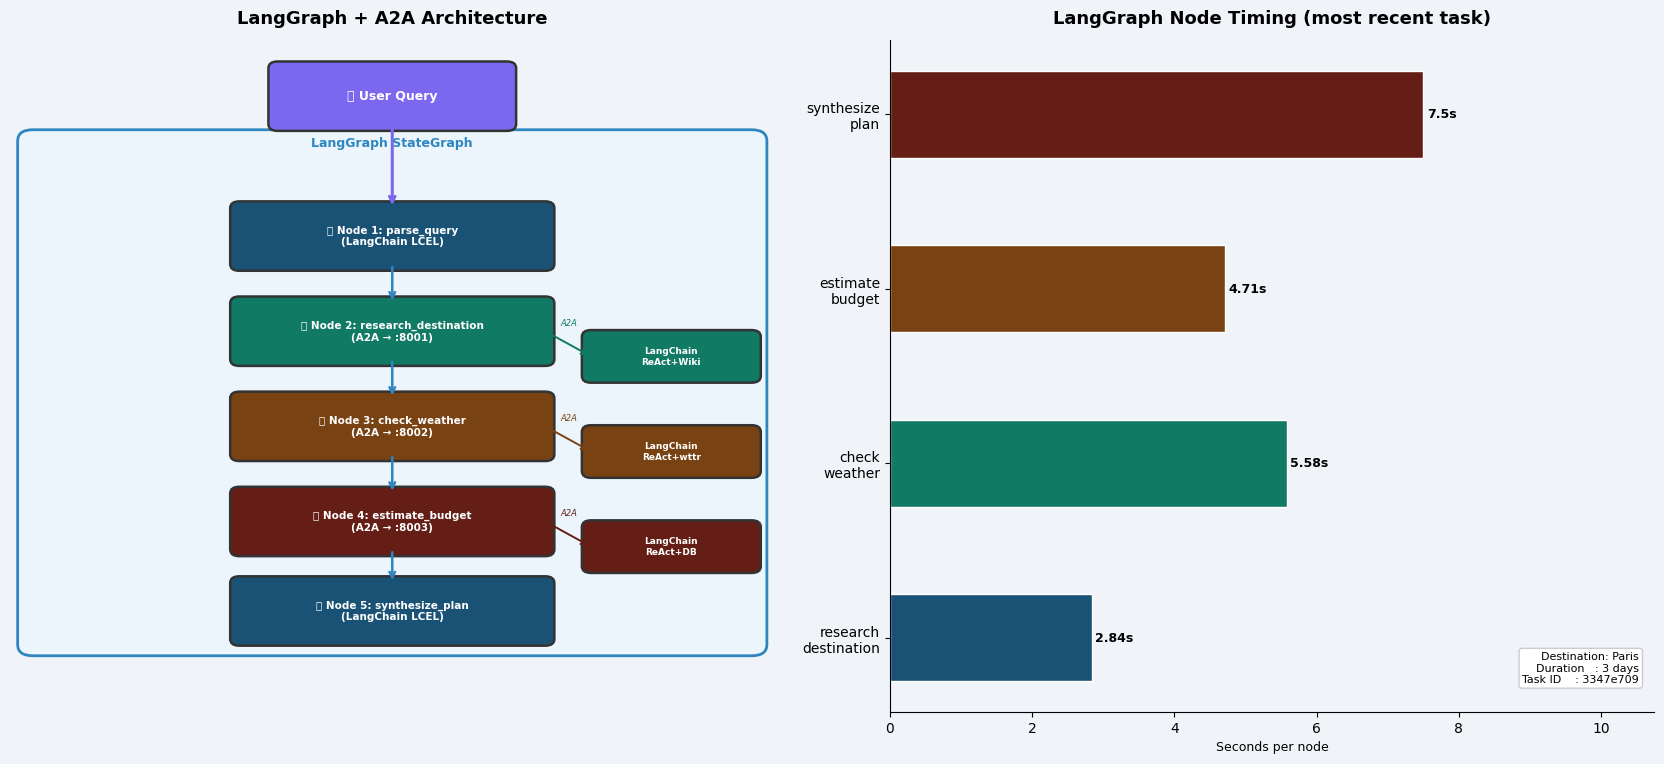

💾 Diagram saved → a2a_langgraph_flow.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.patch.set_facecolor("#f0f4f8")

# ── Left: LangGraph + A2A Architecture ───────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.set_facecolor("#f0f4f8"); ax.axis("off")
ax.set_title("LangGraph + A2A Architecture", fontsize=13, fontweight="bold", pad=12)

def rbox(ax, x, y, w, h, txt, fc, ec="#333", fs=8):
    ax.add_patch(mpatches.FancyBboxPatch((x,y), w, h,
        boxstyle="round,pad=0.12", facecolor=fc, edgecolor=ec, linewidth=1.8, zorder=3))
    ax.text(x+w/2, y+h/2, txt, ha="center", va="center",
            fontsize=fs, color="white", fontweight="bold", multialignment="center", zorder=4)

def arr(ax, x1,y1,x2,y2, col="#555", lw=1.8):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color=col, lw=lw))

# User
rbox(ax, 3.5, 10.5, 3.0, 1.0, "👤 User Query", "#7B68EE", fs=9)
# LangGraph box
lg_box = mpatches.FancyBboxPatch((0.3, 1.2), 9.4, 9.0,
    boxstyle="round,pad=0.2", facecolor="#EBF5FB", edgecolor="#2E86C1", linewidth=2, zorder=1)
ax.add_patch(lg_box)
ax.text(5.0, 10.1, "LangGraph StateGraph", ha="center", fontsize=9, color="#2E86C1",
        fontweight="bold", zorder=5)
# Nodes
rbox(ax, 3.0, 8.0, 4.0, 1.0,  "🔷 Node 1: parse_query\n(LangChain LCEL)", "#1A5276", fs=7.5)
rbox(ax, 3.0, 6.3, 4.0, 1.0,  "🔷 Node 2: research_destination\n(A2A → :8001)", "#117A65", fs=7.5)
rbox(ax, 3.0, 4.6, 4.0, 1.0,  "🔷 Node 3: check_weather\n(A2A → :8002)", "#784212", fs=7.5)
rbox(ax, 3.0, 2.9, 4.0, 1.0,  "🔷 Node 4: estimate_budget\n(A2A → :8003)", "#641E16", fs=7.5)
rbox(ax, 3.0, 1.3, 4.0, 1.0,  "🔷 Node 5: synthesize_plan\n(LangChain LCEL)", "#1A5276", fs=7.5)
# Specialist boxes
rbox(ax, 7.6, 6.0, 2.1, 0.7, "LangChain\nReAct+Wiki", "#117A65", fs=6.5)
rbox(ax, 7.6, 4.3, 2.1, 0.7, "LangChain\nReAct+wttr", "#784212", fs=6.5)
rbox(ax, 7.6, 2.6, 2.1, 0.7, "LangChain\nReAct+DB", "#641E16", fs=6.5)
# Arrows
arr(ax, 5.0, 10.5, 5.0, 9.0, "#7B68EE", 2.2)
arr(ax, 5.0, 8.0, 5.0, 7.3, "#2E86C1")
arr(ax, 5.0, 6.3, 5.0, 5.6, "#2E86C1")
arr(ax, 5.0, 4.6, 5.0, 3.9, "#2E86C1")
arr(ax, 5.0, 2.9, 5.0, 2.3, "#2E86C1")
arr(ax, 7.0, 6.8, 7.6, 6.35, "#117A65", 1.4)
arr(ax, 7.0, 5.1, 7.6, 4.65, "#784212", 1.4)
arr(ax, 7.0, 3.4, 7.6, 2.95, "#641E16", 1.4)
ax.text(7.2, 6.9, "A2A", fontsize=6, color="#117A65", style="italic")
ax.text(7.2, 5.2, "A2A", fontsize=6, color="#784212", style="italic")
ax.text(7.2, 3.5, "A2A", fontsize=6, color="#641E16", style="italic")

# ── Right: Pipeline Performance ───────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#f0f4f8")
ax2.set_title("LangGraph Node Timing (most recent task)", fontsize=13, fontweight="bold", pad=12)

if langgraph_task_log:
    last = langgraph_task_log[-1]
    log_lines = last["node_log"]

    # Extract timing from log entries
    node_labels, node_times = [], []
    for entry in log_lines:
        m = re.search(r'(\w+_\w+|\w+)\s*→.*?\(([\d.]+)s\)', entry)
        if m:
            node_labels.append(m.group(1).replace("_", "\n"))
            node_times.append(float(m.group(2)))

    if node_labels:
        colors_bar = ["#1A5276", "#117A65", "#784212", "#641E16", "#1A5276"]
        bars = ax2.barh(node_labels, node_times,
                        color=colors_bar[:len(node_labels)], edgecolor="white", height=0.5)
        for bar, val in zip(bars, node_times):
            ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                     f"{val}s", va="center", fontsize=9, fontweight="bold")
        ax2.set_xlabel("Seconds per node", fontsize=9)
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)
        if node_times:
            ax2.set_xlim(0, max(node_times) * 1.3 + 1)
    else:
        # Fallback: show task summary if timing not parseable
        ax2.text(0.5, 0.5,
                 f"Task: {last['task_id']}\n"
                 f"Destination: {last['destination']}\n"
                 f"Duration: {last['duration']}\n"
                 f"Synthesis time: {last['elapsed_s']}s\n"
                 f"Status: {last['status']}",
                 ha="center", va="center", fontsize=11, transform=ax2.transAxes,
                 bbox=dict(boxstyle="round", fc="white", ec="#2E86C1"))
        ax2.axis("off")

    info = (f"Destination: {last['destination']}\n"
            f"Duration   : {last['duration']}\n"
            f"Task ID    : {last['task_id']}")
    ax2.text(0.98, 0.04, info, transform=ax2.transAxes,
             fontsize=8, va="bottom", ha="right",
             bbox=dict(boxstyle="round", fc="white", ec="#ccc"))
else:
    ax2.text(0.5, 0.5, "No tasks yet.\nRun the demo cells first!",
             ha="center", va="center", fontsize=12, color="#aaa",
             transform=ax2.transAxes)
    ax2.axis("off")

plt.tight_layout(pad=2.0)
plt.savefig("a2a_langgraph_flow.png", dpi=150, bbox_inches="tight", facecolor="#f0f4f8")
plt.show()
print("💾 Diagram saved → a2a_langgraph_flow.png")

---
## 🔎 Section 11 — LangGraph State Inspection

One of LangGraph's most useful features for debugging: you can inspect the **full state** at any point.

In [19]:
print("🔬 LangGraph State Inspection\n")
print("Running a fresh query and capturing the full final state...\n")

inspect_state = await travel_graph.ainvoke(
    make_initial_state("Plan a 4-day trip to Amsterdam")
)

print("\n" + "═" * 65)
print("📋 FULL STATE SNAPSHOT after pipeline completion:")
print("═" * 65)
for key, value in inspect_state.items():
    if key == "final_plan":
        print(f"\n  {key}:")
        print(f"    [{len(value)} chars — first 200 shown]")
        print(f"    {value[:200]}...")
    elif key == "node_log":
        print(f"\n  {key}: (accumulated across all 5 nodes)")
        for entry in value:
            print(f"    {entry}")
    elif key in ("destination_info", "weather_info", "budget_info"):
        preview = str(value)[:100].replace("\n", " ")
        print(f"  {key}: [{len(str(value))} chars] {preview}...")
    else:
        print(f"  {key}: {value}")

print("\n💡 Key insight: TravelState.node_log shows exactly which nodes ran and how long they took.")
print("   This is possible because node_log uses Annotated[List, operator.add] — it ACCUMULATES.")

🔬 LangGraph State Inspection

Running a fresh query and capturing the full final state...


🔷 [NODE 1] parse_query
   → Destination : Amsterdam
   → Duration    : 4 days
   → Task ID     : 6f221bd1

🔷 [NODE 2] research_destination  →  A2A call :8001
[values] {'messages': [HumanMessage(content='Research this travel destination and provide a comprehensive overview covering attractions, culture, history, and travel tips: Research destination: Amsterdam', additional_kwargs={}, response_metadata={}, id='c1bf611c-9296-4fdc-a81f-77ad96147f0b')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 137, 'total_tokens': 150, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-min

c:\Divya\code\CapStone\.venv\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file c:\Divya\code\CapStone\.venv\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


[updates] {'tools': {'messages': [ToolMessage(content='Page: Amsterdam\nSummary: Amsterdam (Dutch: [ˌɑmstərˈdɑm] ; lit.\u2009\'Dam in the Amstel\') is the capital and largest city of the Netherlands. As of 1 January 2026, it had a population of 941,873 within the city proper, 1,457,018 in the urban area and 2,480,394 in the metropolitan area. Located in the Dutch province of North Holland, Amsterdam is colloquially referred to as the "Venice of the North", for its large number of canals, now a UNESCO World Heritage Site.\nAmsterdam was founded at the mouth of the Amstel river, which was dammed to control flooding. Originally a small fishing village in the 12th century, Amsterdam became a major world port during the Dutch Golden Age of the 17th century, when the Netherlands was an economic powerhouse. Amsterdam was the leading centre for finance and trade, as well as a hub of secular art production. In the 19th and 20th centuries, the city expanded and new neighborhoods and suburbs were

In [20]:
# ── Raw A2A protocol call (still identical to plain A2A notebook) ─────────────
print("🔬 Raw A2A Protocol Inspection (unchanged from plain A2A)\n")
print("The LangChain agent is hidden behind the A2A interface:\n")

rpc_payload = {
    "jsonrpc": "2.0", "id": "inspect-lc-001",
    "method": "message/send",
    "params": {
        "message": {"messageId": str(uuid.uuid4()), "role": "user",
                    "parts": [{"type": "text", "text": "Research destination: Barcelona"}]},
        "context": {"from_agent": "inspector"}
    }
}

print(f"POST http://localhost:8001")
print("Request body:", json.dumps(rpc_payload, indent=2))

async with httpx.AsyncClient(timeout=60) as client:
    r = await client.post("http://localhost:8001", json=rpc_payload)
    resp = r.json()

# Truncate text for display
if "result" in resp and "parts" in resp["result"]:
    for p in resp["result"]["parts"]:
        if "text" in p:
            p["text"] = p["text"][:250] + "  [...]"

print("\nResponse body:")
print(json.dumps(resp, indent=2))
print()
print("✅ Caller sees: JSON-RPC 2.0 response")
print("   Inside:      LangChain 1.x agent + WikipediaQueryRun + ChatOpenAI")
print("   The A2A protocol perfectly encapsulates the LangChain implementation.")

🔬 Raw A2A Protocol Inspection (unchanged from plain A2A)

The LangChain agent is hidden behind the A2A interface:

POST http://localhost:8001
Request body: {
  "jsonrpc": "2.0",
  "id": "inspect-lc-001",
  "method": "message/send",
  "params": {
    "message": {
      "messageId": "28df7ccb-accc-473c-94ba-9bf79134f6f1",
      "role": "user",
      "parts": [
        {
          "type": "text",
          "text": "Research destination: Barcelona"
        }
      ]
    },
    "context": {
      "from_agent": "inspector"
    }
  }
}
[values] {'messages': [HumanMessage(content='Research this travel destination and provide a comprehensive overview covering attractions, culture, history, and travel tips: Research destination: Barcelona', additional_kwargs={}, response_metadata={}, id='c64e1278-ccf1-49ee-b17b-7a04dcbcf3bc')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 

---
## 📚 Section 12 — Key Concepts Review

### What We Built

| Component | Framework | A2A Role |
|---|---|---|
| `destination_app` | LangChain 1.x `create_agent` + WikipediaQueryRun | A2A Specialist Agent (:8001) |
| `weather_app` | LangChain 1.x `create_agent` + custom `fetch_weather_data` | A2A Specialist Agent (:8002) |
| `budget_app` | LangChain 1.x `create_agent` + custom `lookup_travel_costs` | A2A Specialist Agent (:8003) |
| `parse_query_node` | LangChain LCEL (ChatOpenAI) | LangGraph Node 1 |
| `research/weather/budget nodes` | A2AClient.send() | LangGraph Nodes 2-4 |
| `synthesize_plan_node` | LangChain LCEL (ChatOpenAI) | LangGraph Node 5 |
| `TravelState` | TypedDict + `operator.add` | LangGraph state schema |
| `create_a2a_agent` factory | FastAPI | A2A wrapper (UNCHANGED!) |
| JSON-RPC 2.0 protocol | httpx + Pydantic | A2A wire protocol (UNCHANGED!) |

### LangChain Concepts Demonstrated

| Concept | Where Used |
|---|---|
| `ChatOpenAI` | All LLM calls |
| `@lc_tool` decorator | `fetch_weather_data`, `lookup_travel_costs` |
| `WikipediaQueryRun` | Destination research |
| `create_agent` | All 3 specialist agents |
| `recursion_limit` config | Caps tool-call loops |
| `ChatPromptTemplate` | Intent parsing + synthesis |
| LCEL chain (`\|` operator) | `parse_query` and `synthesize_plan` nodes |
| `StrOutputParser` | Parse LLM text output |
| `ainvoke({"messages": ...})` | Async LangChain 1.x agent calls |

### LangGraph Concepts Demonstrated

| Concept | Where Used |
|---|---|
| `StateGraph` | Main workflow builder |
| `TypedDict` state schema | `TravelState` |
| `Annotated[List, operator.add]` | `node_log` accumulation |
| `add_node` | Registering 5 async node functions |
| `add_edge(START, ...)` | Entry point |
| `add_edge(..., END)` | Terminal node |
| `compile()` | Creates runnable graph |
| `ainvoke()` | Async graph execution |
| State inspection | Full state snapshot after run |

---

## 🏋️ Exercises

1. **Parallel fan-out**: Modify nodes 2-4 to run in parallel using a single `gather_info_node` with `asyncio.gather` — measure the speedup  
2. **Conditional routing**: Add a LangGraph conditional edge that skips the weather node for landlocked destinations  
3. **New LangChain tool**: Add a `currency_converter` tool that fetches live FX rates via `httpx` + a public API and integrate it into the budget agent  
4. **Different LLM provider**: Swap `ChatOpenAI` for `ChatAnthropic` (`anthropic==0.68.0` in the lock file) — observe how the A2A layer is unaffected  
5. **LangGraph checkpointing**: Add `InMemorySaver` (`langgraph.checkpoint.memory`) to persist orchestrator state between calls  
6. **Error recovery node**: Add a LangGraph node that runs on agent failure and retries or provides cached data